# Erasure Channel auf der Bitübertragungsschicht

Dieses Notebook zeigt einen **Erasure Channel** aus Sicht der **Bitübertragungsschicht / Physical Layer**.

Der Empfänger betrachtet den empfangenen Signalwert und entscheidet zwischen drei möglichen Ausgabewerten:

- sicher niedrig → Bit `0`
- sicher hoch → Bit `1`
- unsicher → Erasure `?`

Als Leitungscodierung verwenden wir NRZ (Non-Return to Zero):

$
0 \mapsto -1, \qquad 1 \mapsto +1
$

Durch AWGN wird daraus beim Empfänger ein verrauschter Messwert.

## Soft Decision und Erasure Decision

Der physikalische Empfänger erhält keinen diskreten Wert `0`, `1` oder `?`, sondern einen kontinuierlichen Messwert.

Im AWGN-Modell gilt:

$
r_i = s_i + n_i
$

mit

$
s_i \in \{-1, +1\}
$

und

$
n_i \sim \mathcal{N}(0,\sigma^2)
$

Der Wert $r_i$ enthält bereits Zuverlässigkeitsinformation:

- Ein großer positiver Wert spricht stark für eine gesendete `1`.
- Ein großer negativer Wert spricht stark für eine gesendete `0`.
- Ein Wert nahe bei $0$ ist unsicher.

### Hard Decision
Wenn der Empfänger abhängig von $r_i$ hart zwischen `0` und `1` entscheidet, handelt es sich um einen Hard Decision Empfänger.


### Soft Decision
Wenn der Empfänger den kontinuierlichen Wert $r_i$ weitergibt, spricht man von einer Soft Decision.

### Erasure Decision
Wenn der Empfänger $r_i$ auf `0`, `1` oder `?` abbildet, haben wir es mit einer Erasure Decision zu tun:

$
Y_i =
\begin{cases}
0, & r_i < -a\\
?, & -a \le r_i \le a \\
1, & r_i > a
\end{cases}
$

Der Wert $a$ markiert obere und untere Schwelle eines Bandes, in welchem die Entscheidung unsicher ist.

Die Erasure-Ausgabe kann als Quantisierung der Soft Information verstanden werden.

## 1. Vorbereitung

Wir importieren NumPy für die Simulation und Matplotlib für die Visualisierung.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

## 2. Bits erzeugen

Wir benötigen Dazen zur Übertragung. Dazu erzeugen wir 1000 zufällige Bits und zeigen die ersten dreißig an.

In [3]:
N = 1000
bits = np.random.randint(0, 2, size=N)

print(bits[:30])

[1 0 1 0 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0]


## 3. Bits auf Signalwerte abbilden

Wir führen die Leitungscodierung (NRZ) durch:

$
0 \mapsto -1, \qquad 1 \mapsto +1
$

Anzeige der ersten dreißig Bit.

In [4]:
signals = 2 * bits - 1

print(signals[:30])

[ 1 -1  1 -1  1  1  1  1 -1  1 -1  1 -1  1 -1 -1 -1 -1  1 -1 -1 -1  1  1
 -1 -1  1  1 -1 -1]


## 4. Rauschen auf dem Physical Layer

Störungen durch thermisches Rauschen, Verstärker, Leitungen oder Funkkanäle verändern die Amplitude des übertragenen Signals. 

Der Kanal ist analog (zeit- und wertdiskret), aus Gründen der Einfachheit verzichten wir auf den zeitlichen Aspekt. Jedes Bit bleibt uns daher direkt als Bit erhalten und muss nicht erst mittels Taktsynchronisation lokalisiert werden.

Wir modellieren das empfangene Signal als

$
r_i = s_i + n_i
$

Dabei ist:

- $s_i$: gesendeter Signalwert
- $n_i$: Rauschanteil
- $r_i$: empfangener Signalwert

Für das Rauschen verwenden wir ein additives weißes gaußsches Rauschen (AWGN):

$
n_i \sim \mathcal{N}(0, \sigma^2)
$

Damit gilt:

- **gaußverteilt**: Die Amplituden folgen einer Normalverteilung.
- **Mittelwert 0**: Das Rauschen verschiebt das Signal im Mittel nicht systematisch.
- **Varianz $\sigma^2$**: Die Stärke des Rauschens wird durch $\sigma$ bestimmt.
- **weiß**: Die Rauschwerte verschiedener Symbole sind voneinander unabhängig.
- **additiv**: Das Rauschen wird zum gesendeten Signal addiert.

Nach dem Hinzugügen des Rauschens zeigen wir einige Bits an. Die Werte schwanken.

In [ ]:
sigma = 0.7  # Standardabweichung für Stärke des Rauschens
noise = np.random.normal(loc=0, scale=sigma, size=N) # gaußverteiltes Rauschen erzeugen
received = signals + noise # Addition zu gesendeten Signalen

# einige Bits anzeigen
print(received[:10])

[ 0.28944015 -1.1159001   1.71752811 -0.8979563   1.74354716 -0.12864503
 -0.50457359 -0.3728048  -1.0184054   0.60397398]


## 5. Empfangene Signalwerte visualisieren

Die Linie bei `0` markiert die harte Entscheidungsschwelle eines normalen Empfängers.

- Messwert unter 0 → `0`
- Messwert ab 0 → `1`

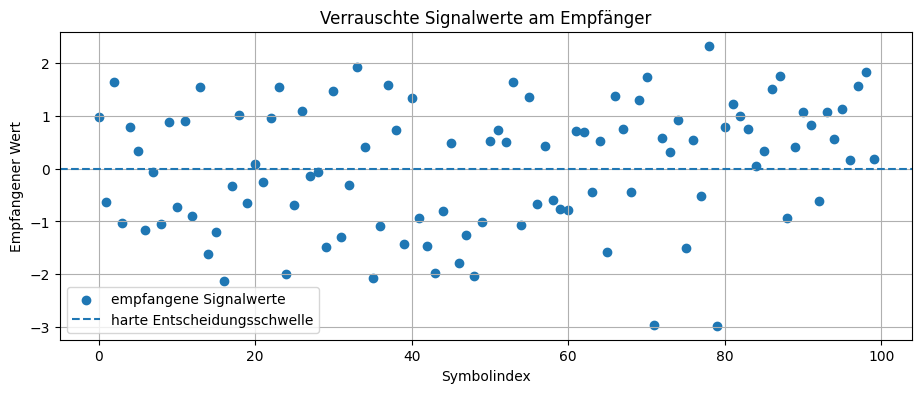

In [6]:
plt.figure(figsize=(11, 4))
plt.scatter(np.arange(100), received[:100], label="empfangene Signalwerte")
plt.axhline(0, linestyle="--", label="harte Entscheidungsschwelle")
plt.xlabel("Symbolindex")
plt.ylabel("Empfangener Wert")
plt.title("Verrauschte Signalwerte am Empfänger")
plt.grid(True)
plt.legend()
plt.show()

## 6. Harte Entscheidung ohne Erasure

Ein normaler Empfänger muss sich entscheiden:

$
Y \in \{0,1\}
$

Auch Messwerte nahe bei `0` werden hart als `0` oder `1` interpretiert.

In [7]:
hard_decision = (received >= 0).astype(int)

hard_errors = np.sum(hard_decision != bits)
hard_ber = hard_errors / N

print(f"Anzahl Bitfehler bei harter Entscheidung: {hard_errors}")
print(f"Bitfehlerrate bei harter Entscheidung: {hard_ber:.3f}")

Anzahl Bitfehler bei harter Entscheidung: 68
Bitfehlerrate bei harter Entscheidung: 0.068


In [8]:
print("Index | gesendet | Messwert | harte Entscheidung")
print("-" * 48)

for i in range(20):
    print(f"{i:5d} | {bits[i]:8d} | {received[i]:8.3f} | {hard_decision[i]:17d}")

Index | gesendet | Messwert | harte Entscheidung
------------------------------------------------
    0 |        1 |    0.988 |                 1
    1 |        0 |   -0.622 |                 0
    2 |        1 |    1.648 |                 1
    3 |        0 |   -1.034 |                 0
    4 |        1 |    0.784 |                 1
    5 |        1 |    0.337 |                 1
    6 |        1 |   -1.158 |                 0
    7 |        1 |   -0.063 |                 0
    8 |        0 |   -1.049 |                 0
    9 |        1 |    0.877 |                 1
   10 |        0 |   -0.718 |                 0
   11 |        1 |    0.911 |                 1
   12 |        0 |   -0.888 |                 0
   13 |        1 |    1.551 |                 1
   14 |        0 |   -1.620 |                 0
   15 |        0 |   -1.201 |                 0
   16 |        0 |   -2.125 |                 0
   17 |        0 |   -0.319 |                 0
   18 |        1 |    1.027 |         

## 7. Erasure-Zone einführen

Jetzt erlauben wir dem Empfänger, unsichere Messwerte nicht hart zu entscheiden (Soft Decision).

Wir definieren eine Schwelle $a$. Abhängig davon gilt:

$
r < -a \Rightarrow 0
$

$
r > a \Rightarrow 1
$

$
-a \le r \le a \Rightarrow ?
$

Das Fragezeichen `?` kennzeichnet, dass dieses Symbol nicht zuverlässig entscheidbar ist.
Bei einem echten Soft-Decision-Empfänger 

In [9]:
erasure_threshold = 0.4

erasure_decision = np.full(N, "?", dtype=object)
erasure_decision[received < -erasure_threshold] = "0"
erasure_decision[received > erasure_threshold] = "1"

print(erasure_decision[:30])

['1' '0' '1' '0' '1' '?' '0' '?' '0' '1' '0' '1' '0' '1' '0' '0' '0' '?'
 '1' '0' '?' '?' '1' '1' '0' '0' '1' '?' '?' '0']


## 8. Erasure-Zone darstellen

Der Bereich zwischen `-a` und `+a` ist die Unsicherheitszone.

Werte in dieser Zone werden nicht als `0` oder `1` entschieden, sondern als `?` markiert.

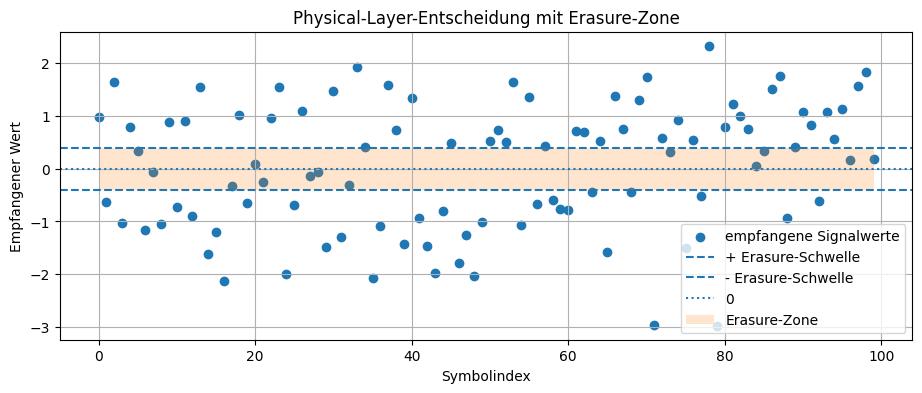

In [10]:
plt.figure(figsize=(11, 4))
plt.scatter(np.arange(100), received[:100], label="empfangene Signalwerte")
plt.axhline(erasure_threshold, linestyle="--", label="+ Erasure-Schwelle")
plt.axhline(-erasure_threshold, linestyle="--", label="- Erasure-Schwelle")
plt.axhline(0, linestyle=":", label="0")
plt.fill_between(
    np.arange(100),
    -erasure_threshold,
    erasure_threshold,
    alpha=0.2,
    label="Erasure-Zone"
)
plt.xlabel("Symbolindex")
plt.ylabel("Empfangener Wert")
plt.title("Physical-Layer-Entscheidung mit Erasure-Zone")
plt.grid(True)
plt.legend()
plt.show()

## 9. Erasures und Fehlentscheidungen zählen

Zu unterscheiden ist zwischen

- **Erasure Rate**: Anteil der Symbole, die als `?` markiert werden
- **Fehlerrate unter entschiedenen Symbolen**: Anteil falscher `0`/`1`-Entscheidungen, nachdem `?` ausgeschlossen wurde

In unserem einfachen Modell wird keine Fehlerkorrektur und keine Fehlererkennung verwendet. Wir zählen nur, was durch die Physical-Layer-Entscheidung entsteht.

In [11]:
is_erasure = erasure_decision == "?"
not_erased = ~is_erasure

num_erasures = np.sum(is_erasure)
erasure_rate = num_erasures / N

if np.sum(not_erased) > 0:
    decided_bits = erasure_decision[not_erased].astype(int)
    errors_among_decided = np.sum(decided_bits != bits[not_erased])
    error_rate_among_decided = errors_among_decided / np.sum(not_erased)
else:
    errors_among_decided = 0
    error_rate_among_decided = np.nan

print(f"Erasure-Schwelle: {erasure_threshold}")
print(f"Anzahl Erasures: {num_erasures}")
print(f"Erasure Rate: {erasure_rate:.3f}")
print(f"Fehler unter entschiedenen Bits: {errors_among_decided}")
print(f"Fehlerrate unter entschiedenen Bits: {error_rate_among_decided:.3f}")

Erasure-Schwelle: 0.4
Anzahl Erasures: 183
Erasure Rate: 0.183
Fehler unter entschiedenen Bits: 16
Fehlerrate unter entschiedenen Bits: 0.020


In [12]:
print("Index | gesendet | Messwert | harte Entscheidung | Erasure-Entscheidung")
print("-" * 75)

for i in range(30):
    print(
        f"{i:5d} | {bits[i]:8d} | {received[i]:8.3f} |"
        f" {hard_decision[i]:17d} | {erasure_decision[i]:20s}"
    )

Index | gesendet | Messwert | harte Entscheidung | Erasure-Entscheidung
---------------------------------------------------------------------------
    0 |        1 |    0.988 |                 1 | 1                   
    1 |        0 |   -0.622 |                 0 | 0                   
    2 |        1 |    1.648 |                 1 | 1                   
    3 |        0 |   -1.034 |                 0 | 0                   
    4 |        1 |    0.784 |                 1 | 1                   
    5 |        1 |    0.337 |                 1 | ?                   
    6 |        1 |   -1.158 |                 0 | 0                   
    7 |        1 |   -0.063 |                 0 | ?                   
    8 |        0 |   -1.049 |                 0 | 0                   
    9 |        1 |    0.877 |                 1 | 1                   
   10 |        0 |   -0.718 |                 0 | 0                   
   11 |        1 |    0.911 |                 1 | 1                   


## 10. Trade-Off: Schwelle variieren

Je größer die Erasure-Zone wird, desto mehr Symbole werden als `?` markiert.

Dafür sinkt meistens die Fehlerrate unter den Symbolen, die überhaupt noch entschieden werden.

$
\text{mehr Erasures} \quad \leftrightarrow \quad \text{weniger falsche harte Entscheidungen}
$

In [13]:
thresholds = np.linspace(0, 1.5, 80)

erasure_rates = []
error_rates_among_decided = []
kept_rates = []

for threshold in thresholds:
    decision = np.full(N, "?", dtype=object)
    decision[received < -threshold] = "0"
    decision[received > threshold] = "1"
    
    is_erasure = decision == "?"
    not_erased = ~is_erasure
    
    erasure_rates.append(np.mean(is_erasure))
    kept_rates.append(np.mean(not_erased))
    
    if np.sum(not_erased) > 0:
        decided_bits = decision[not_erased].astype(int)
        error_rates_among_decided.append(np.mean(decided_bits != bits[not_erased]))
    else:
        error_rates_among_decided.append(np.nan)

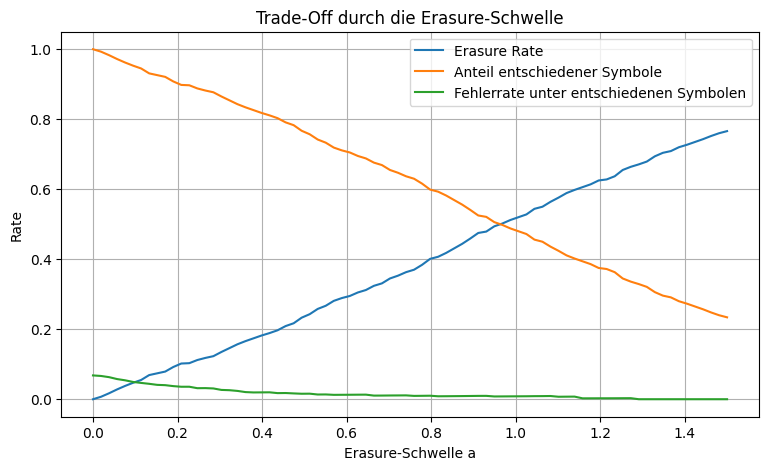

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(thresholds, erasure_rates, label="Erasure Rate")
plt.plot(thresholds, kept_rates, label="Anteil entschiedener Symbole")
plt.plot(thresholds, error_rates_among_decided, label="Fehlerrate unter entschiedenen Symbolen")
plt.xlabel("Erasure-Schwelle a")
plt.ylabel("Rate")
plt.title("Trade-Off durch die Erasure-Schwelle")
plt.grid(True)
plt.legend()
plt.show()

## 11. Einfluss des Rauschens

Jetzt variieren wir die Standardabweichung $\sigma$. 
Je größer $\sigma$, desto stärker streuen die empfangenen Werte.

Bei fester Erasure-Schwelle führt stärkeres Rauschen zu

- mehr harten Bitfehlern,
- mehr unsicheren Symbole,
- mehr falschen Entscheidungen unter den nicht gelöschten Symbolen.

In [15]:
sigmas = np.linspace(0.1, 2.0, 60)
fixed_threshold = 0.4

hard_bers = []
erasure_rates_noise = []
error_rates_decided_noise = []

for sigma in sigmas:
    noise = np.random.normal(loc=0, scale=sigma, size=N)
    received_sigma = signals + noise
    
    hard_decision_sigma = (received_sigma >= 0).astype(int)
    hard_bers.append(np.mean(hard_decision_sigma != bits))
    
    decision = np.full(N, "?", dtype=object)
    decision[received_sigma < -fixed_threshold] = "0"
    decision[received_sigma > fixed_threshold] = "1"
    
    is_erasure = decision == "?"
    not_erased = ~is_erasure
    
    erasure_rates_noise.append(np.mean(is_erasure))
    
    if np.sum(not_erased) > 0:
        decided_bits = decision[not_erased].astype(int)
        error_rates_decided_noise.append(np.mean(decided_bits != bits[not_erased]))
    else:
        error_rates_decided_noise.append(np.nan)

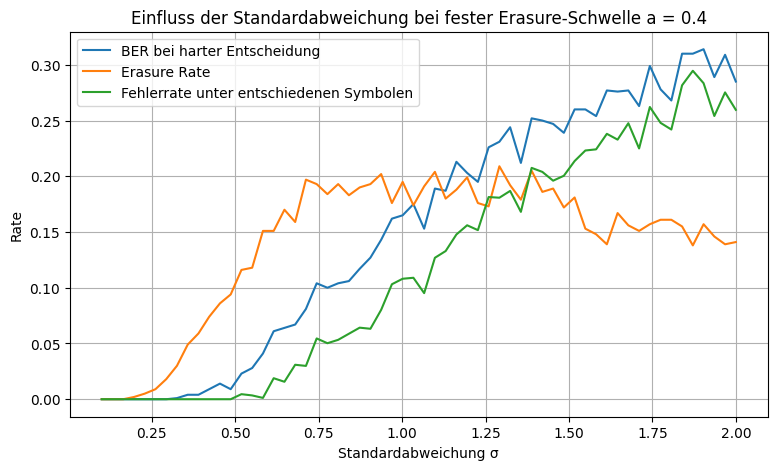

In [17]:
plt.figure(figsize=(9, 5))
plt.plot(sigmas, hard_bers, label="BER bei harter Entscheidung")
plt.plot(sigmas, erasure_rates_noise, label="Erasure Rate")
plt.plot(sigmas, error_rates_decided_noise, label="Fehlerrate unter entschiedenen Symbolen")
plt.xlabel("Standardabweichung σ")
plt.ylabel("Rate")
plt.title(f"Einfluss der Standardabweichung bei fester Erasure-Schwelle a = {fixed_threshold}")
plt.grid(True)
plt.legend()
plt.show()